# Task 1 — Inductive Biases and Feature Representations

This notebook probes how three frozen visual backbones — **ResNet-50**
(CNN), **ViT-B/16** (vision transformer), and **CLIP ViT-B/32** (contrastive
image-text) — differ in their inductive biases toward **color**, **shape vs.
texture**, **translation**, and **local patch structure**, and how those
differences show up both in downstream predictions and in the geometry of
their frozen feature spaces.

**Pipeline:** train a linear probe per backbone on frozen STL-10 features →
evaluate all backbones (+ CLIP zero-shot) on a fixed 500-image balanced test
subset → apply four families of pixel-space interventions to that *same*
subset → measure accuracy / consistency / representation stability under
each intervention.

All stochastic choices (splits, subset selection, color-swap pairing, patch
permutations, projection fits) are seeded from a single master seed
(`SEED = 6304`) via `utils.config.make_rng`, so every artifact here is
reproducible from a clean run of this notebook.


## 1. Setup & Configuration

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image

from utils.config import (
    SEED, DEVICE, USE_CUDA, IMG_SIZE, STL10_CLASSES,
    RESULTS_DIR, CACHE_DIR, FIGURES_DIR,
    seed_everything, make_rng, autocast_ctx, save_json, load_json,
)
from utils import backbones as bb
from utils import transforms as tr
from utils import data as dm
from utils import metrics as mx
from utils.adain import AdaINStyleTransfer
from analysis import cue_conflict_calibration as cuecal

seed_everything(SEED)
print(f"Device: {DEVICE} | CUDA: {USE_CUDA} | classes: {STL10_CLASSES}")


Device: cuda | CUDA: True | classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


**Execution environment.** The populated run used a CUDA-capable environment
with the pretrained ImageNet/OpenAI-CLIP backbones, STL-10, and local AdaIN
encoder/decoder checkpoints. Restart the kernel and run top-to-bottom after
changing calibration settings so cached and downstream artifacts remain aligned.


## 2. Backbone Wrapper Classes

Each backbone is wrapped so that the shared pipeline can call
`.forward_features(images_0_1)` uniformly, with backbone-specific
normalization applied *inside* the wrapper (never baked into cached
images — see `utils/backbones.py`). All backbones are frozen and kept in
`eval()` mode permanently.

| Backbone | Weights | Representation |
|---|---|---|
| ResNet-50 | `IMAGENET1K_V2` | 2048-d global-average-pooled feature |
| ViT-B/16 | `IMAGENET1K_V1` | `[CLS]` token embedding (768-d) |
| CLIP ViT-B/32 | OpenAI `openai` weights | L2-normalized image embedding (512-d) |


In [2]:
backbone_dict = bb.build_backbones(device=DEVICE)
resnet, vit, clip = backbone_dict["resnet50"], backbone_dict["vit_b_16"], backbone_dict["clip_vit_b_32"]
for name, model in backbone_dict.items():
    n_params = sum(p.numel() for p in model.parameters())
    print(f"{name}: {n_params/1e6:.1f}M params, feature_dim={model.feature_dim}, frozen={not any(p.requires_grad for p in model.parameters())}")


/home/ayaan/custom_venvs/cuda_pytorch/lib/python3.14/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


resnet50: 23.5M params, feature_dim=2048, frozen=True
vit_b_16: 86.6M params, feature_dim=768, frozen=True
clip_vit_b_32: 151.3M params, feature_dim=512, frozen=True


In [3]:
# Sanity check: CLIP zero-shot prompts
print([f"a photo of a {c}." for c in STL10_CLASSES])


['a photo of a airplane.', 'a photo of a bird.', 'a photo of a car.', 'a photo of a cat.', 'a photo of a deer.', 'a photo of a dog.', 'a photo of a horse.', 'a photo of a monkey.', 'a photo of a ship.', 'a photo of a truck.']


## 3. Dataset Loading, Stratified Split, Linear-Head Training

- Dataset: **STL-10** (`torchvision.datasets.STL10`), 10 classes.
- Images are resized to 224×224 and kept as `[0,1]` float RGB tensors — no
  backbone normalization at this stage (Sec. 4 of the spec: normalization is
  applied last, per-backbone).
- Stratified 80/20 split of the **official train partition**, seed 6304.
- One linear head (`in_features -> 10`) per backbone, trained on **cached**
  frozen features (extracted once, reused across all 50 epochs).
- AdamW, lr=1e-3, weight_decay=1e-4, max 50 epochs, early stopping after 5
  epochs without validation-accuracy improvement.


In [4]:
train_ds, test_ds = dm.get_datasets(download=True)
print(f"STL-10 train: {len(train_ds)}, test: {len(test_ds)}")

train_subset, val_subset = dm.stratified_split(train_ds, train_frac=0.8, seed_name="stratified_split")
print(f"Stratified split -> train: {len(train_subset)}, val: {len(val_subset)}")

train_loader_raw = dm.make_loader(train_subset, batch_size=128, shuffle=False)
val_loader_raw = dm.make_loader(val_subset, batch_size=128, shuffle=False)


STL-10 train: 5000, test: 8000
Stratified split -> train: 4000, val: 1000


In [5]:
# Extract & cache frozen features for train/val once per backbone (clean condition).
linear_heads = {}
head_histories = {}

for name, model in backbone_dict.items():
    t0 = time.time()
    train_feat = dm.extract_features(model, train_loader_raw, condition="clean_train")
    val_feat = dm.extract_features(model, val_loader_raw, condition="clean_val")
    print(f"[{name}] feature extraction: {time.time()-t0:.1f}s "
          f"(train={train_feat['features'].shape}, val={val_feat['features'].shape})")

    head, history = dm.train_linear_head(
        train_feats=train_feat["features"], train_labels=train_feat["labels"],
        val_feats=val_feat["features"], val_labels=val_feat["labels"],
        in_features=model.feature_dim, num_classes=len(STL10_CLASSES),
        seed=SEED,
    )
    linear_heads[name] = head
    head_histories[name] = history
    print(f"[{name}] best val acc = {history['best_val_acc']:.4f} "
          f"(stopped after {history['epochs_run']} epochs)")

save_json({k: {kk: vv for kk, vv in v.items() if kk != 'train_loss'} for k, v in head_histories.items()},
          RESULTS_DIR / "linear_head_training_summary.json")


[resnet50] feature extraction: 23.0s (train=torch.Size([4000, 2048]), val=torch.Size([1000, 2048]))


/mnt/Windows/Ayaan files/parhai/uni/3 fall/ATML/PA1/repo/task1/utils/data.py:273: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_scaler)


Training linear head:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50:   0%|          | 0/16 [00:00<?, ?batch/s]

Epoch 2/50:   0%|          | 0/16 [00:00<?, ?batch/s]

...

Epoch 7/50:   0%|          | 0/16 [00:00<?, ?batch/s]

Epoch 8/50:   0%|          | 0/16 [00:00<?, ?batch/s]

Epoch 9/50:   0%|          | 0/16 [00:00<?, ?batch/s]

Epoch 10/50:   0%|          | 0/16 [00:00<?, ?batch/s]

[clip_vit_b_32] best val acc = 0.9760 (stopped after 10 epochs)


## 4. Class-Balanced Evaluation Subset (500 images)

Selected once from the **official STL-10 test partition**, seed 6304, and
reused **unchanged** for every model and every intervention in the rest of
this notebook. If a class has fewer than 50 available images the shortfall
is logged explicitly (STL-10's test split has 800 images/class, so no
shortfall is expected here, but the logic below handles it generically).


In [6]:
eval_subset = dm.select_eval_subset(test_ds, total=500, seed_name="eval_subset")
save_json(eval_subset, RESULTS_DIR / "eval_subset_ids.json")

print(f"Selected {eval_subset['total_selected']} images "
      f"(target {eval_subset['total_requested']}, {eval_subset['per_class_target']}/class)")
if eval_subset["shortfall_log"]:
    print("Shortfalls:", eval_subset["shortfall_log"])
else:
    print("No shortfalls — every class reached its target count.")

eval_image_ids = eval_subset["image_ids"]
eval_labels = eval_subset["labels"]
eval_indices = eval_subset["indices"]


Selected 500 images (target 500, 50/class)
No shortfalls — every class reached its target count.


In [7]:
from torch.utils.data import Subset

eval_ds_clean = Subset(test_ds, eval_indices)
eval_loader_clean = dm.make_loader(eval_ds_clean, batch_size=100, shuffle=False)


## 5. Shared Transform Pipeline

Implemented once in `utils/transforms.py` and reused for every backbone:
`to_grayscale3`, `class_swap_color_transfer` (+ its LAB stats/derangement
helpers), `translate_reflect`, and `patch_shuffle`. Each operates on
`[0,1]` RGB tensors at 224×224 — the exact same pixels are then fed through
every backbone's own `.normalize()`, guaranteeing pixel-identical inputs
across models for a given condition (Sec. 4 of the spec).

A helper below runs any backbone + linear head over a full `DataLoader`
that yields already-intervened images, producing predictions/logits/labels/
ids in one pass (used repeatedly in Steps 1–5).


In [8]:
@torch.no_grad()
def run_head_over_loader(model, head, loader, condition, cache=True):
    feat_bundle = dm.extract_features(model, loader, condition=condition, cache=cache)
    feats = feat_bundle["features"].to(DEVICE)
    labels = feat_bundle["labels"]
    ids = feat_bundle["image_ids"]
    head.eval()
    with autocast_ctx():
        logits = head(feats)
    preds = logits.argmax(dim=-1).cpu().numpy().tolist()
    return {
        "preds": preds, "labels": labels, "image_ids": ids,
        "logits": logits.float().cpu(), "features": feat_bundle["features"],
    }


@torch.no_grad()
def run_clip_zero_shot_over_loader(clip_model, loader, condition):
    all_preds, all_labels, all_ids, all_conf = [], [], [], []
    for imgs, lbls, ids in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        pred, conf = clip_model.zero_shot_predict(imgs)
        all_preds.extend(pred.cpu().tolist())
        all_conf.extend(conf.cpu().tolist())
        all_labels.extend([int(x) for x in lbls])
        all_ids.extend(list(ids))
    return {"preds": all_preds, "labels": all_labels, "image_ids": all_ids, "confidences": all_conf}


## 6. Step 1 — Clean Baseline

Run all 3 trained linear heads + CLIP zero-shot on the 500-image clean
eval subset. These per-image predictions are the reference point every
later "consistency vs. clean" metric compares against.


In [9]:
clean_results = {}
for name in ["resnet50", "vit_b_16"]:
    r = run_head_over_loader(backbone_dict[name], linear_heads[name], eval_loader_clean, condition="clean_eval")
    clean_results[name] = r

# CLIP: both the trained linear head AND zero-shot are reported.
clean_results["clip_vit_b_32_linear"] = run_head_over_loader(
    backbone_dict["clip_vit_b_32"], linear_heads["clip_vit_b_32"], eval_loader_clean, condition="clean_eval")
clean_results["clip_vit_b_32_zeroshot"] = run_clip_zero_shot_over_loader(
    backbone_dict["clip_vit_b_32"], eval_loader_clean, condition="clean_eval")


In [10]:
rows = []
for name, r in clean_results.items():
    acc = mx.accuracy(r["preds"], r["labels"])
    f1 = mx.macro_f1(r["preds"], r["labels"])
    if "logits" in r:
        conf = mx.mean_max_softmax_confidence(r["logits"])
    else:
        conf = float(np.mean(r["confidences"]))
    rows.append({"model": name, "accuracy": acc, "macro_f1": f1, "mean_max_confidence": conf})

clean_baseline_df = pd.DataFrame(rows)
clean_baseline_df.to_csv(RESULTS_DIR / "clean_baseline.csv", index=False)
clean_baseline_df


,model,accuracy,macro_f1,mean_max_confidence
0,resnet50,0.990,0.989999,0.918369
1,vit_b_16,0.994,0.993998,0.966571
2,clip_vit_b_32_linear,0.982,0.981884,0.155044
3,clip_vit_b_32_zeroshot,0.958,0.956925,0.936498


**CLIP-linear confidence comparability.** The raw mean maximum softmax
confidence of `clip_vit_b_32_linear` is not directly comparable to the other
three decision rules. Its inputs are L2-normalized CLIP features, while its
weight-decay-regularized linear head has no learned logit scale analogous to
CLIP's `logit_scale.exp()` used by the zero-shot rule. Small linear-head logit
magnitudes can therefore produce a flatter softmax despite high accuracy. We
report the required raw value without post-hoc rescaling and do not interpret
its absolute magnitude as worse calibration.


In [11]:
# Persist per-image predictions for every model (needed for later consistency computations).
clean_preds_by_model = {name: dict(zip(r["image_ids"], r["preds"])) for name, r in clean_results.items()}
save_json(clean_preds_by_model, RESULTS_DIR / "clean_predictions_per_image.json")


## 7. Step 2 — Color Bias

### 7a. Grayscale
Removes all chrominance, replicates luminance to 3 channels. Preserves
geometry, edges, and texture exactly — isolates how much each model relies
on color alone.

### 7b. Class-swapped color statistics (LAB Reinhard-style transfer)
For each eval image of class *c*, we linearly remap its LAB channel
statistics (mean/std) to match a different, fixed "donor" class's typical
statistics — computed from the **training split** only (never from the eval
subset). This is a per-pixel **affine** recoloring: the same channel-wise
`(x - mean_c)/std_c * std_donor + mean_donor` map is applied identically at
every pixel, so it **cannot** alter shape, texture, or geometry — it only
shifts the image's global color palette toward another class's. This is
mechanistically distinct from grayscale (which *removes* color) and gives a
second, complementary color-sensitivity probe.

**Hypothesis (stated before results):** CLIP and ViT, trained with more
texture/shape-agnostic global pooling and (for CLIP) natural-language
supervision, are expected to be more robust to color shifts than the CNN,
which is known from the literature (Geirhos et al. 2019) to be more
texture/color-sensitive; class-swapped color statistics that mimic a
plausible *other* class's palette should hurt the CNN's accuracy more than
grayscale does, since it introduces a misleading rather than merely absent
color cue.


In [12]:
# --- Compute per-class LAB stats from the TRAINING split (not eval subset) ---
train_labels_all = np.array(train_ds.base.labels)
images_by_class = {}
loader_full_train = dm.make_loader(train_subset, batch_size=256, shuffle=False)
# Collect raw [0,1] images per class from the 80% train partition.
imgs_accum = {c: [] for c in range(len(STL10_CLASSES))}
for imgs, lbls, ids in loader_full_train:
    for img, lbl in zip(imgs, lbls):
        c = int(lbl)
        if len(imgs_accum[c]) < 200:  # cap per class for tractable LAB-stat computation
            imgs_accum[c].append(img)
images_by_class = {c: torch.stack(v) for c, v in imgs_accum.items() if len(v) > 0}

class_lab_stats = tr.compute_class_lab_stats(images_by_class)
color_swap_mapping = tr.make_class_derangement(len(STL10_CLASSES), seed_name="color_swap_pairing")
assert all(k != v for k, v in color_swap_mapping.items()), "derangement must have no fixed points"

save_json({STL10_CLASSES[k]: STL10_CLASSES[v] for k, v in color_swap_mapping.items()},
          RESULTS_DIR / "color_swap_mapping.json")
print("Color-swap donor mapping:", {STL10_CLASSES[k]: STL10_CLASSES[v] for k, v in color_swap_mapping.items()})


Color-swap donor mapping: {'airplane': 'bird', 'bird': 'car', 'car': 'airplane', 'cat': 'monkey', 'deer': 'truck', 'dog': 'cat', 'horse': 'ship', 'monkey': 'dog', 'ship': 'horse', 'truck': 'deer'}


In [13]:
class GrayscaleDataset(torch.utils.data.Dataset):
    def __init__(self, base_subset):
        self.base = base_subset
    def __len__(self):
        return len(self.base)
    def __getitem__(self, i):
        img, lbl, iid = self.base[i]
        return tr.to_grayscale3(img.unsqueeze(0)).squeeze(0), lbl, iid


class ColorSwapDataset(torch.utils.data.Dataset):
    def __init__(self, base_subset, mapping, class_lab_stats):
        self.base = base_subset
        self.mapping = mapping
        self.class_lab_stats = class_lab_stats
    def __len__(self):
        return len(self.base)
    def __getitem__(self, i):
        img, lbl, iid = self.base[i]
        out = tr.class_swap_color_transfer(img.unsqueeze(0), int(lbl), self.mapping, self.class_lab_stats)
        return out.squeeze(0), lbl, iid


gray_loader = dm.make_loader(GrayscaleDataset(eval_ds_clean), batch_size=100, shuffle=False)
swap_loader = dm.make_loader(ColorSwapDataset(eval_ds_clean, color_swap_mapping, class_lab_stats), batch_size=100, shuffle=False)


In [14]:
def evaluate_condition(condition_name, loader, include_clip_zeroshot=True):
    results = {}
    for name in ["resnet50", "vit_b_16"]:
        results[name] = run_head_over_loader(backbone_dict[name], linear_heads[name], loader, condition=condition_name)
    results["clip_vit_b_32_linear"] = run_head_over_loader(
        backbone_dict["clip_vit_b_32"], linear_heads["clip_vit_b_32"], loader, condition=condition_name)
    if include_clip_zeroshot:
        results["clip_vit_b_32_zeroshot"] = run_clip_zero_shot_over_loader(
            backbone_dict["clip_vit_b_32"], loader, condition=condition_name)
    return results


def summarize_vs_clean(condition_name, condition_results, clean_results):
    rows = []
    for name, r in condition_results.items():
        acc = mx.accuracy(r["preds"], r["labels"])
        clean_acc = mx.accuracy(clean_results[name]["preds"], clean_results[name]["labels"])
        # Align by image_id in case ordering differs between loaders.
        clean_map = dict(zip(clean_results[name]["image_ids"], clean_results[name]["preds"]))
        aligned_clean_preds = [clean_map[i] for i in r["image_ids"]]
        consistency = mx.prediction_consistency(aligned_clean_preds, r["preds"])
        rows.append({
            "condition": condition_name, "model": name,
            "accuracy": acc, "accuracy_delta_vs_clean": acc - clean_acc,
            "consistency_vs_clean": consistency,
        })
    return rows


In [15]:
gray_results = evaluate_condition("grayscale", gray_loader)
swap_results = evaluate_condition("color_swap", swap_loader)

color_bias_rows = (
    summarize_vs_clean("grayscale", gray_results, clean_results)
    + summarize_vs_clean("color_swap", swap_results, clean_results)
)
color_bias_df = pd.DataFrame(color_bias_rows)
color_bias_df.to_csv(RESULTS_DIR / "color_bias_results.csv", index=False)
color_bias_df


,condition,model,accuracy,accuracy_delta_vs_clean,consistency_vs_clean
0,grayscale,resnet50,0.968,-0.022,0.970
1,grayscale,vit_b_16,0.976,-0.018,0.978
2,grayscale,clip_vit_b_32_linear,0.970,-0.012,0.976
3,grayscale,clip_vit_b_32_zeroshot,0.952,-0.006,0.956
4,color_swap,resnet50,0.990,0.000,0.996
5,color_swap,vit_b_16,0.996,0.002,0.998
6,color_swap,clip_vit_b_32_linear,0.976,-0.006,0.994
7,color_swap,clip_vit_b_32_zeroshot,0.952,-0.006,0.986


## 8. Step 3 — Shape vs. Texture (Cue-Conflict via AdaIN)

**Class pairs (≥5, both directions).** Chosen to have visually distinct
shape *and* texture, avoiding pairs that already look similar:

| Pair | Rationale |
|---|---|
| cat ↔ truck | organic vs. rigid/mechanical shape, fur vs. metal/paint texture |
| bird ↔ ship | very different silhouettes, feather vs. hull texture |
| dog ↔ car | four-legged vs. wheeled silhouette, fur vs. metal/glass |
| horse ↔ airplane | ground quadruped vs. winged aircraft, very different textures |
| monkey ↔ deer | both animals but differ enough in silhouette/fur pattern to be a meaningful within-domain control pair |

Each pair is stylized in both directions (content=A/style=B and
content=B/style=A), targeting ≥20 accepted conflicts per pair-direction
(≥200 total across 5 pairs × 2 directions = 10 buckets).

**Candidate-quality rule (defined before any model sees these images and
using no model predictions):** the initial run uses SSIM to the grayscale
content image plus a pixel-standard-deviation degeneracy check. The SSIM
cutoff began at 0.20 only to construct the calibration cohort; Section 8b
selected the final 0.30 threshold against a preregistered human rubric.
`DEGENERATE_STD_THRESHOLD = 0.02` always rejects near-flat decoder failures.
Neither calibration nor final filtering uses any classifier output.


In [16]:
# Requires a pretrained AdaIN checkpoint (encoder is a truncated VGG-19,
# decoder is the mirrored decoder network) — see utils/adain.py docstring
# for a public source. Point these paths at local files before running.
VGG_WEIGHTS_PATH = "models/vgg_normalised.pth"      # <-- set this
DECODER_WEIGHTS_PATH = "models/decoder.pth"          # <-- set this

adain_model = AdaINStyleTransfer(
    vgg_weights_path=VGG_WEIGHTS_PATH,
    decoder_weights_path=DECODER_WEIGHTS_PATH,
).to(DEVICE)


In [17]:
CUE_CONFLICT_PAIRS = [
    ("cat", "truck"),
    ("bird", "ship"),
    ("dog", "car"),
    ("horse", "airplane"),
    ("monkey", "deer"),
]
TARGET_PER_BUCKET = 30  # post-calibration buffer for >=200 reasonably balanced accepted images
class_to_idx = {c: i for i, c in enumerate(STL10_CLASSES)}


In [18]:
# Build per-class pools of (image_tensor, image_id) from the eval subset,
# used as both content and style sources for the pairs above (per spec:
# "Pull the eval-subset's 500 images ... as content/style sources").
eval_imgs_by_class = {c: [] for c in range(len(STL10_CLASSES))}
for imgs, lbls, ids in eval_loader_clean:
    for img, lbl, iid in zip(imgs, lbls, ids):
        eval_imgs_by_class[int(lbl)].append((img, iid))

for c, items in eval_imgs_by_class.items():
    print(STL10_CLASSES[c], len(items))


airplane 50
bird 50
car 50
cat 50
deer 50
dog 50
horse 50
monkey 50
ship 50
truck 50


In [19]:
rng_cue = make_rng("cue_conflict_sampling")
rejection_log = {}
candidate_records = []  # all decoded candidates, retained for threshold calibration
accepted_records = []  # list of dicts: content_class, texture_class, direction, content_id, style_id, image tensor
rejected_records = []

def sample_pairs(pool_a, pool_b, n, rng):
    idx_a = rng.integers(0, len(pool_a), size=n)
    idx_b = rng.integers(0, len(pool_b), size=n)
    return [(pool_a[i], pool_b[j]) for i, j in zip(idx_a, idx_b)]

for (cls_a, cls_b) in CUE_CONFLICT_PAIRS:
    ia, ib = class_to_idx[cls_a], class_to_idx[cls_b]
    for direction, (content_cls, style_cls) in [("A_shape_B_texture", (ia, ib)), ("B_shape_A_texture", (ib, ia))]:
        bucket_key = f"{cls_a}-{cls_b}:{direction}"
        pairs = sample_pairs(eval_imgs_by_class[content_cls], eval_imgs_by_class[style_cls], TARGET_PER_BUCKET, rng_cue)
        n_accept, n_reject = 0, 0
        for (content_img, content_id), (style_img, style_id) in pairs:
            with torch.no_grad():
                stylized = adain_model.style_transfer(content_img.unsqueeze(0), style_img.unsqueeze(0), alpha=1.0)
            content_np = content_img.permute(1, 2, 0).cpu().numpy()
            stylized_np = stylized.squeeze(0).permute(1, 2, 0).cpu().numpy()
            check = mx.is_valid_cue_conflict(content_np, stylized_np)
            record = {
                "pair": f"{cls_a}-{cls_b}", "direction": direction, "bucket_key": bucket_key,
                "content_class": STL10_CLASSES[content_cls], "texture_class": STL10_CLASSES[style_cls],
                "content_class_idx": content_cls, "texture_class_idx": style_cls,
                "content_id": content_id, "style_id": style_id,
                "image": stylized.squeeze(0).cpu(), "ssim": check["ssim_to_content"],
                "pixel_std": check["pixel_std"], "degenerate": check["degenerate"],
            }
            candidate_records.append(record)
            if check["accepted"]:
                n_accept += 1
                accepted_records.append(record)
            else:
                n_reject += 1
                rejected_records.append(record)
        rejection_log[bucket_key] = {"accepted": n_accept, "rejected": n_reject, "target": TARGET_PER_BUCKET}
        print(bucket_key, rejection_log[bucket_key])

save_json(rejection_log, RESULTS_DIR / "cue_conflict_rejection_log.json")
cue_manifest = pd.DataFrame([
    {"cue_id": cuecal.cue_conflict_id(rec), **{k: v for k, v in rec.items() if k != "image"}}
    for rec in accepted_records
])
cue_manifest.to_csv(RESULTS_DIR / "cue_conflict_manifest.csv", index=False)
print(f"Total accepted cue-conflict images: {len(accepted_records)}")
assert len(accepted_records) >= 200, "Increase TARGET_PER_BUCKET if the 200-image target was not reached after rejections."


cat-truck:A_shape_B_texture {'accepted': 25, 'rejected': 5, 'target': 30}
cat-truck:B_shape_A_texture {'accepted': 24, 'rejected': 6, 'target': 30}
bird-ship:A_shape_B_texture {'accepted': 26, 'rejected': 4, 'target': 30}
bird-ship:B_shape_A_texture {'accepted': 27, 'rejected': 3, 'target': 30}
dog-car:A_shape_B_texture {'accepted': 30, 'rejected': 0, 'target': 30}
dog-car:B_shape_A_texture {'accepted': 21, 'rejected': 9, 'target': 30}
horse-airplane:A_shape_B_texture {'accepted': 27, 'rejected': 3, 'target': 30}
horse-airplane:B_shape_A_texture {'accepted': 30, 'rejected': 0, 'target': 30}
monkey-deer:A_shape_B_texture {'accepted': 26, 'rejected': 4, 'target': 30}
monkey-deer:B_shape_A_texture {'accepted': 27, 'rejected': 3, 'target': 30}
Total accepted cue-conflict images: 263


In [20]:
class CueConflictDataset(torch.utils.data.Dataset):
    def __init__(self, records):
        self.records = records
    def __len__(self):
        return len(self.records)
    def __getitem__(self, i):
        r = self.records[i]
        # label is unused downstream (we classify shape/texture/other from
        # the content/texture class indices stored per-record instead of a
        # single ground-truth label); we pass content_class_idx as a
        # placeholder "label" purely so the DataLoader/caching machinery
        # (which expects (image, label, id)) works unchanged.
        return r["image"], r["content_class_idx"], cuecal.cue_conflict_id(r)

cue_ds = CueConflictDataset(accepted_records)
cue_loader = dm.make_loader(cue_ds, batch_size=100, shuffle=False)
cue_results_by_model = evaluate_condition("cue_conflict", cue_loader)


In [21]:
shape_texture_rows = []
for name, r in cue_results_by_model.items():
    id_to_pred = dict(zip(r["image_ids"], r["preds"]))
    decisions_by_pair = {}
    for i, rec in enumerate(accepted_records):
        iid = cuecal.cue_conflict_id(rec)
        pred = id_to_pred[iid]
        decision = mx.classify_shape_texture(pred, rec["content_class_idx"], rec["texture_class_idx"])
        decisions_by_pair.setdefault(rec["pair"], []).append(decision)
        decisions_by_pair.setdefault("__all__", []).append(decision)
    for pair_key, decisions in decisions_by_pair.items():
        summary = mx.shape_bias_summary(decisions)
        shape_texture_rows.append({"model": name, "pair": pair_key, **summary})

shape_texture_df = pd.DataFrame(shape_texture_rows)
shape_texture_df.to_csv(RESULTS_DIR / "shape_texture_results.csv", index=False)
shape_texture_df[shape_texture_df["pair"] == "__all__"]


,model,pair,n_total,n_shape,n_texture,n_other,shape_bias_pct,coverage_pct
1,resnet50,__all__,263,50,60,153,45.454545,41.825095
7,vit_b_16,__all__,263,113,32,118,77.931034,55.133080
13,clip_vit_b_32_linear,__all__,263,122,25,116,82.993197,55.893536
19,clip_vit_b_32_zeroshot,__all__,263,125,27,111,82.236842,57.794677


### Curated examples

A small gallery of agreement/disagreement/failure cases across the three
backbones, for the report's qualitative "informative cases" requirement.


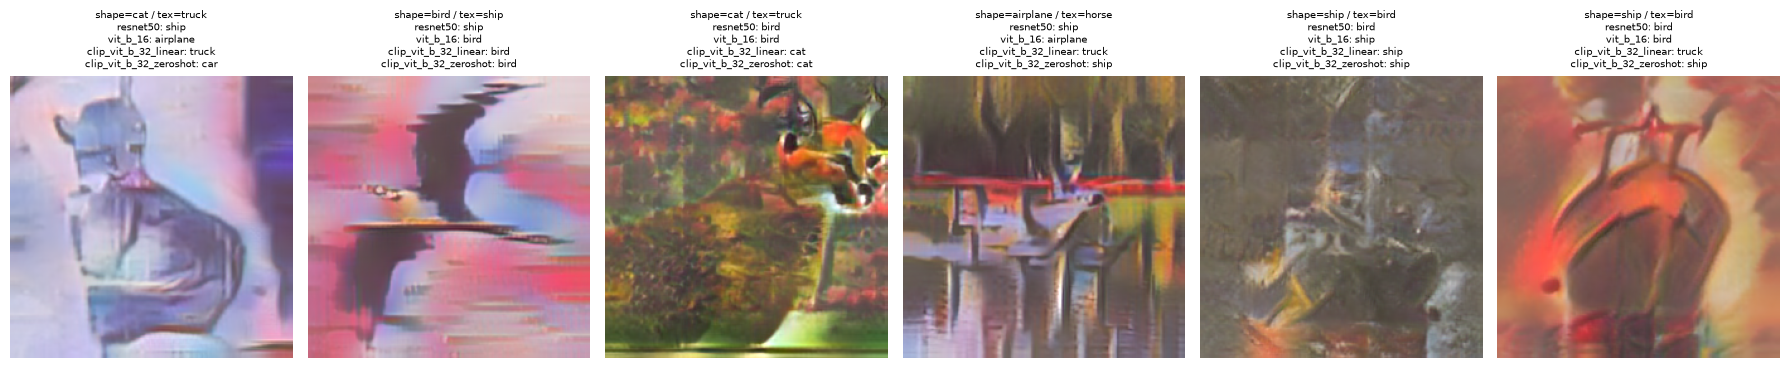

In [22]:
def show_cue_conflict_gallery(records, results_by_model, n=6, seed_name="gallery_pick"):
    rng = make_rng(seed_name)
    pick = rng.choice(len(records), size=min(n, len(records)), replace=False)
    fig, axes = plt.subplots(1, len(pick), figsize=(3 * len(pick), 3.5))
    if len(pick) == 1:
        axes = [axes]
    for ax, i in zip(axes, pick):
        rec = records[i]
        img = rec["image"].permute(1, 2, 0).numpy()
        ax.imshow(np.clip(img, 0, 1))
        ax.axis("off")
        iid = cuecal.cue_conflict_id(rec)
        title_lines = [f"shape={rec['content_class']} / tex={rec['texture_class']}"]
        for name, r in results_by_model.items():
            pred_idx = dict(zip(r["image_ids"], r["preds"]))[iid]
            title_lines.append(f"{name}: {STL10_CLASSES[pred_idx]}")
        ax.set_title("\n".join(title_lines), fontsize=7)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "cue_conflict_gallery.png", dpi=150)
    plt.show()

show_cue_conflict_gallery(accepted_records, cue_results_by_model)


## 8b. Cue-Conflict Rejection Threshold Calibration

The SSIM threshold is calibrated against a human review sample before any
model prediction is used. The sample is stratified across all ten
pair/direction buckets and keyed by stable content/style/direction IDs, so a
restarted session cannot silently attach a rating to a different image.

**Pre-registered pass/fail rubric.** **Fail** if the content shape is no longer
recognizable as its stated class, the style texture is effectively absent, or
the image is muddy/degenerate enough that neither cue is interpretable.
Otherwise **pass**. This wording was fixed before the ratings were collected.


In [23]:
calibration_config_path = RESULTS_DIR / "cue_conflict_calibration_config.json"
completed_sweep_path = RESULTS_DIR / "cue_conflict_threshold_sweep.csv"
if completed_sweep_path.exists() and calibration_config_path.exists():
    # Preserve the original 220-image calibration cohort after the final
    # generation buffer is raised to 30 candidates per bucket.
    calibration_config = load_json(calibration_config_path)
    ssim_summary = calibration_config["ssim_summary"]
    SWEEP_MIN = calibration_config["sweep_min"]
    SWEEP_MAX = calibration_config["sweep_max"]
    SWEEP_STEP = calibration_config["sweep_step"]
    SWEEP_THRESHOLDS = np.asarray(calibration_config["thresholds"], dtype=float)
    print("Using completed calibration config:", calibration_config)
else:
    ssim_summary = cuecal.plot_ssim_distribution(candidate_records)
    print("SSIM distribution summary:", ssim_summary)
    # Inspect the histogram before review. These explicit values are saved
    # before rating so threshold selection cannot move after seeing labels.
    SWEEP_MIN = 0.20
    SWEEP_MAX = 0.50
    SWEEP_STEP = 0.05
    SWEEP_THRESHOLDS = np.round(
        np.arange(SWEEP_MIN, SWEEP_MAX + SWEEP_STEP / 2, SWEEP_STEP), 10
    )
    save_json(
        {
            "ssim_summary": ssim_summary,
            "sweep_min": SWEEP_MIN,
            "sweep_max": SWEEP_MAX,
            "sweep_step": SWEEP_STEP,
            "thresholds": SWEEP_THRESHOLDS.tolist(),
            "range_decision": "Retained the preregistered 0.20--0.50 range: the distribution spans this interval and its lower tail is decision-relevant.",
            "tie_break": "kappa ties within 1e-9 select the stricter (higher) threshold",
            "positive_class": "fail",
        },
        calibration_config_path,
    )
print("Sweep thresholds:", SWEEP_THRESHOLDS)


Using completed calibration config: {'ssim_summary': {'count': 220, 'min': 0.21104690423125802, 'q05': 0.26873486116098405, 'median': 0.41742162634066027, 'q95': 0.5773951539590528, 'max': 0.7646439319509131}, 'sweep_min': 0.2, 'sweep_max': 0.5, 'sweep_step': 0.05, 'thresholds': [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5], 'range_decision': 'Retained the preregistered 0.20--0.50 range: the 220-image distribution spans this interval (min 0.211, q05 0.269, median 0.417) and its lower tail is decision-relevant.', 'tie_break': 'kappa ties within 1e-9 select the stricter (higher) threshold', 'positive_class': 'fail'}
Sweep thresholds: [0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]


In [24]:
sweep_path = RESULTS_DIR / "cue_conflict_threshold_sweep.csv"
if sweep_path.exists():
    # A completed calibration must not be resampled after the Phase 3
    # candidate buffer changes from 22 to 30 images per bucket.
    completed_sweep = pd.read_csv(sweep_path)
    selected = completed_sweep.loc[completed_sweep["selected"].astype(str).str.lower() == "true"]
    print("Calibration already complete; selected row:")
    display(selected)
else:
    calibration_sample = cuecal.sample_for_review(
        candidate_records,
        sample_frac=0.10,
        seed_name="cue_conflict_threshold_audit",
    )
    print(
        f"Manual review sample: {len(calibration_sample)} unique images across "
        f"{len({record['bucket_key'] for record in calibration_sample})} buckets"
    )
    review_session = cuecal.ReviewSession(
        calibration_sample,
        thresholds=SWEEP_THRESHOLDS,
        ratings_path=RESULTS_DIR / "cue_conflict_manual_ratings.jsonl",
    )
    review_session.show()


Calibration already complete; selected row:


,threshold,agreement_pct,cohen_kappa,fail_precision,fail_recall,fail_f1,manual_pass,manual_fail,predicted_fail,selected,ranking_metric,tie_break_invoked,sweep_min,sweep_max,sweep_count
0,0.3,75.0,0.418605,1.0,0.375,0.545455,12,8,3,True,cohen_kappa,False,0.2,0.5,7


After the final rating, the widget automatically writes the complete sweep
table and kappa plot and prints the selected threshold. Then update
`SSIM_MIN_THRESHOLD` in `utils/metrics.py`, change `TARGET_PER_BUCKET` to 30,
restart the kernel, and rerun the notebook top-to-bottom. Confirm at least 200
images remain accepted and that rejection counts are recorded per bucket before
using any downstream shape-bias, gallery, stability, or t-SNE output.


## 9. Step 4 — Translation

Reflection-pad then shifted-crop each of the 500 eval images by
δ ∈ {0, 8, 16, 32} px in each of 4 cardinal directions, keeping the output
224×224. For each δ, results are averaged across the 4 directions.

**Hypothesis (stated before results):** ResNet-50's convolutional/pooling
stack has some built-in (if imperfect) translation equivariance, whereas
ViT's patch-position embeddings and CLIP's patchified ViT encoder are
expected to be more sensitive to absolute spatial position, so we expect
the CNN's accuracy/consistency curves to degrade more gracefully with δ
than the transformer-based models.


In [25]:
translation_rows = []
delta_values = [0, 8, 16, 32]

class TranslateDataset(torch.utils.data.Dataset):
    def __init__(self, base_subset, delta, direction):
        self.base = base_subset
        self.delta = delta
        self.direction = direction
    def __len__(self):
        return len(self.base)
    def __getitem__(self, i):
        img, lbl, iid = self.base[i]
        if self.delta == 0:
            out = img
        else:
            out = tr.translate_reflect(img.unsqueeze(0), self.delta, self.direction).squeeze(0)
        return out, lbl, iid

for delta in delta_values:
    directions = [tr.DIRECTIONS[0]] if delta == 0 else list(tr.DIRECTIONS)
    per_direction_metrics = {name: {"acc": [], "cons": []} for name in
                              ["resnet50", "vit_b_16", "clip_vit_b_32_linear", "clip_vit_b_32_zeroshot"]}
    for direction in directions:
        loader = dm.make_loader(TranslateDataset(eval_ds_clean, delta, direction), batch_size=100, shuffle=False)
        cond_name = f"translate_d{delta}_{direction}"
        results = evaluate_condition(cond_name, loader)
        for name, r in results.items():
            acc = mx.accuracy(r["preds"], r["labels"])
            clean_map = dict(zip(clean_results[name]["image_ids"], clean_results[name]["preds"]))
            aligned_clean_preds = [clean_map[i] for i in r["image_ids"]]
            cons = mx.prediction_consistency(aligned_clean_preds, r["preds"])
            per_direction_metrics[name]["acc"].append(acc)
            per_direction_metrics[name]["cons"].append(cons)
    for name, m in per_direction_metrics.items():
        translation_rows.append({
            "delta": delta, "model": name,
            "accuracy": float(np.mean(m["acc"])), "consistency_vs_clean": float(np.mean(m["cons"])),
        })

translation_df = pd.DataFrame(translation_rows)
translation_df.to_csv(RESULTS_DIR / "translation_results.csv", index=False)
translation_df


,delta,model,accuracy,consistency_vs_clean
0,0,resnet50,0.9900,1.0000
1,0,vit_b_16,0.9940,1.0000
2,0,clip_vit_b_32_linear,0.9820,1.0000
3,0,clip_vit_b_32_zeroshot,0.9580,1.0000
4,8,resnet50,0.9875,0.9975
5,8,vit_b_16,0.9910,0.9930
6,8,clip_vit_b_32_linear,0.9765,0.9835
7,8,clip_vit_b_32_zeroshot,0.9500,0.9615
8,16,resnet50,0.9875,0.9955
9,16,vit_b_16,0.9945,0.9975


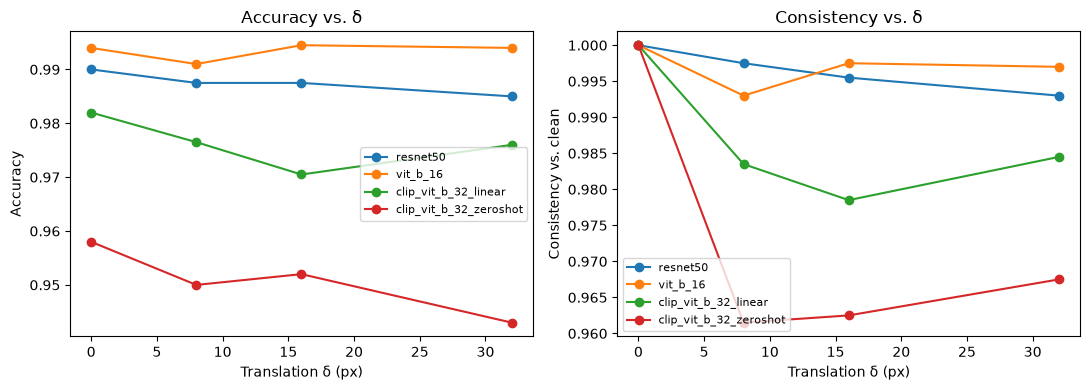

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name in translation_df["model"].unique():
    sub = translation_df[translation_df["model"] == name].sort_values("delta")
    axes[0].plot(sub["delta"], sub["accuracy"], marker="o", label=name)
    axes[1].plot(sub["delta"], sub["consistency_vs_clean"], marker="o", label=name)
axes[0].set_xlabel("Translation δ (px)"); axes[0].set_ylabel("Accuracy"); axes[0].set_title("Accuracy vs. δ")
axes[1].set_xlabel("Translation δ (px)"); axes[1].set_ylabel("Consistency vs. clean"); axes[1].set_title("Consistency vs. δ")
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "translation_curves.png", dpi=150)
plt.show()


## 10. Step 5 — Patch Structure

Each 224×224 eval image is divided into a 4×4 grid of 56×56 patches and
given a **fixed, per-image, seeded, non-identity permutation** (same
permutation reused across every backbone for that image).

**Hypothesis (stated before results):** ViT and CLIP's ViT encoder process
images as an unordered-ish set of patch tokens with learned positional
embeddings, while ResNet's convolutions rely heavily on local spatial
continuity across the whole receptive field; we expect patch-shuffling to
hurt the CNN's accuracy/consistency more severely than the ViT-based
models, since shuffling breaks the CNN's larger, spatially contiguous
receptive fields more thoroughly than it breaks patch-token identity for
the transformers.


In [27]:
patch_permutations = {iid: tr.make_patch_permutation(iid, grid=4).tolist() for iid in eval_image_ids}
save_json(patch_permutations, RESULTS_DIR / "patch_permutations.json")

class PatchShuffleDataset(torch.utils.data.Dataset):
    def __init__(self, base_subset):
        self.base = base_subset
    def __len__(self):
        return len(self.base)
    def __getitem__(self, i):
        img, lbl, iid = self.base[i]
        perm = np.array(patch_permutations[iid])
        out = tr.patch_shuffle(img, perm, grid=4)
        return out, lbl, iid

shuffle_loader = dm.make_loader(PatchShuffleDataset(eval_ds_clean), batch_size=100, shuffle=False)
shuffle_results = evaluate_condition("patch_shuffle", shuffle_loader)
patch_shuffle_rows = summarize_vs_clean("patch_shuffle", shuffle_results, clean_results)
patch_shuffle_df = pd.DataFrame(patch_shuffle_rows)
patch_shuffle_df.to_csv(RESULTS_DIR / "patch_shuffle_results.csv", index=False)
patch_shuffle_df


,condition,model,accuracy,accuracy_delta_vs_clean,consistency_vs_clean
0,patch_shuffle,resnet50,0.922,-0.068,0.926
1,patch_shuffle,vit_b_16,0.942,-0.052,0.946
2,patch_shuffle,clip_vit_b_32_linear,0.808,-0.174,0.810
3,patch_shuffle,clip_vit_b_32_zeroshot,0.790,-0.168,0.782


## 11. Step 6 — Representation Analysis

For **grayscale**, **cue-conflict**, **translation (δ=32px, averaged across
the 4 directions)**, and **patch-shuffle**, we reuse the already-cached
frozen feature vectors (extracted while running Steps 2–5 above; no
recomputation needed here — `dm.extract_features` transparently returns the
cached tensors keyed per image by `(backbone, condition, image-id)` to compute a
representation-stability score `I_T` per backbone × intervention, and fit a
single 2D t-SNE projection per backbone on the combined clean+transformed
features.

In [28]:
REPR_CONDITIONS = ["grayscale", "cue_conflict", "translate_d32_up", "patch_shuffle"]
# NOTE: translation representation stability uses one representative
# direction (up) at delta=32, as permitted by the spec ("pick one
# representative delta ... or aggregate — decide and document"); we pick a
# single direction rather than an average across directions specifically
# for the *representation* analysis, since I_T and the projection need one
# concrete feature vector per image, whereas the earlier scalar accuracy/
# consistency metrics were already averaged across directions.

repr_backbones = {"resnet50": resnet, "vit_b_16": vit, "clip_vit_b_32": clip}

def get_cached_feats(backbone_name, condition, image_ids):
    cached = dm.load_cached_features(backbone_name, condition, image_ids)
    assert cached is not None, f"Expected cached features for {backbone_name}/{condition}; run the corresponding step above first."
    id_to_row = {iid: i for i, iid in enumerate(cached["image_ids"])}
    order = [id_to_row[iid] for iid in image_ids]
    return cached["features"][order]

I_T_rows = []
for backbone_name in repr_backbones:
    clean_feats = get_cached_feats(backbone_name, "clean_eval", eval_image_ids)
    for cond in REPR_CONDITIONS:
        if cond == "cue_conflict":
            cond_ids = [cuecal.cue_conflict_id(rec) for rec in accepted_records]
            cond_feats = get_cached_feats(backbone_name, cond, cond_ids)
            # cue-conflict has no 1:1 correspondence with a single clean
            # image (each stylization mixes a content + a style image), so
            # I_T here is computed against the ORIGINAL CONTENT image's
            # clean feature instead of a matched eval-subset index.
            content_ids = [rec["content_id"] for rec in accepted_records]
            ref_feats = get_cached_feats(backbone_name, "clean_eval", content_ids)
        else:
            cond_feats = get_cached_feats(backbone_name, cond, eval_image_ids)
            ref_feats = clean_feats
        i_t = mx.representation_stability(ref_feats, cond_feats)
        I_T_rows.append({"backbone": backbone_name, "condition": cond, "I_T": i_t})

I_T_df = pd.DataFrame(I_T_rows)
I_T_df.to_csv(RESULTS_DIR / "representation_stability.csv", index=False)
I_T_df.pivot(index="backbone", columns="condition", values="I_T")


condition,cue_conflict,grayscale,patch_shuffle,translate_d32_up
backbone,,,,
clip_vit_b_32,0.699053,0.887592,0.755161,0.973476
resnet50,0.230862,0.804720,0.694613,0.935094
vit_b_16,0.213906,0.737712,0.634183,0.940526


**Projection method:** t-SNE (`sklearn.manifold.TSNE`, `perplexity=30`,
`metric="cosine"`, `init="pca"`, seed derived from `SEED=6304` via
`make_rng("tsne")`) was chosen over UMAP for its strong local-neighborhood
preservation on datasets of this scale (~1,000 points per plot: 500 clean +
500 transformed), which is what we care about here (do clean/transformed
pairs of the *same* image stay close?), and because it needs no extra
dependency beyond scikit-learn. One projection is fit **per backbone per
intervention**, on the **combined** clean+transformed feature matrix, so
both conditions live in the same 2D space — but different backbones/
interventions each get an independent fit, and their absolute coordinates
are **not** comparable to one another (only relative structure within a
single panel is meaningful).


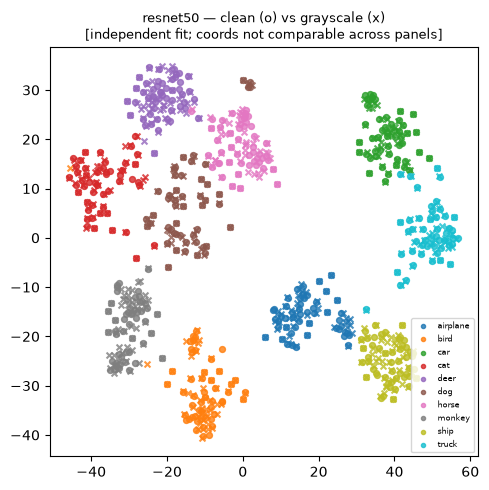

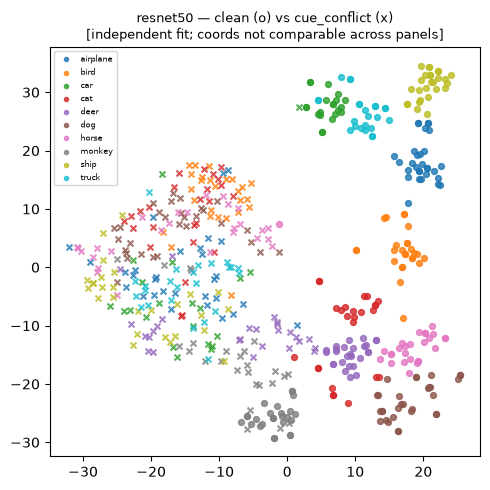

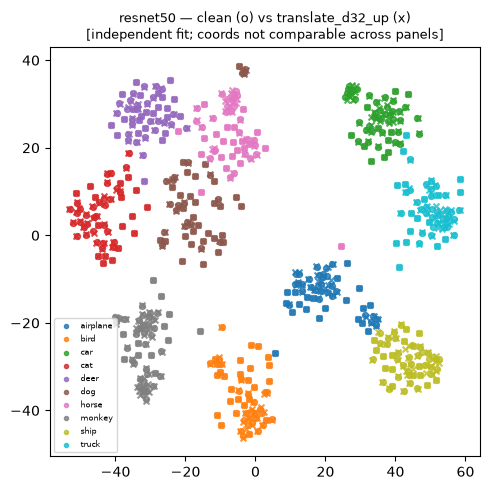

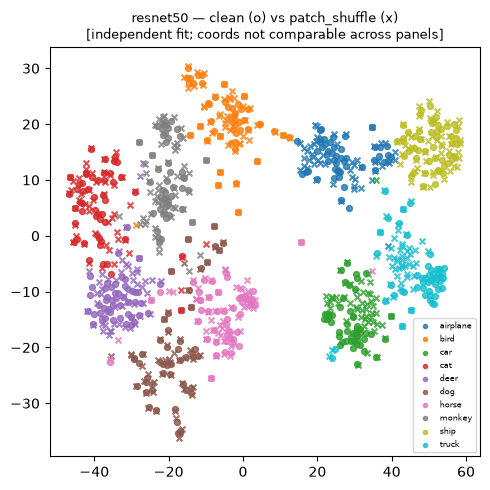

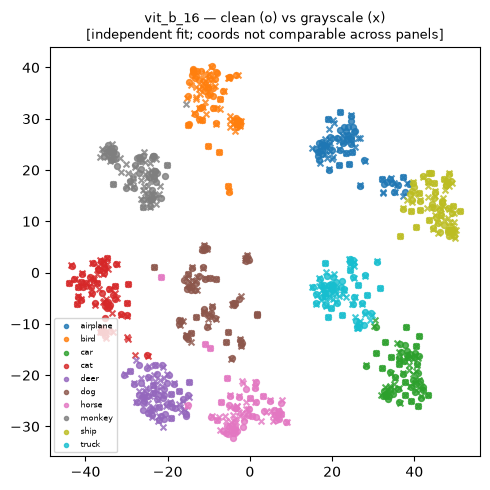

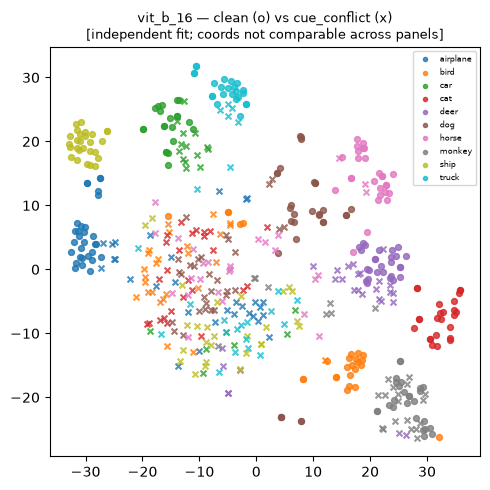

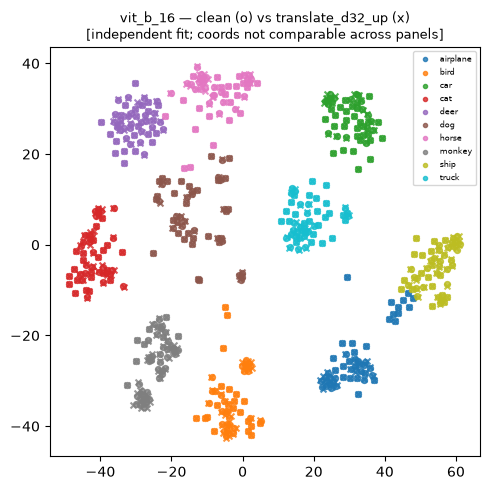

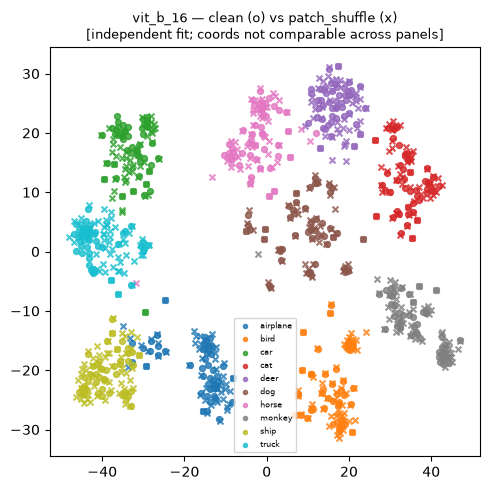

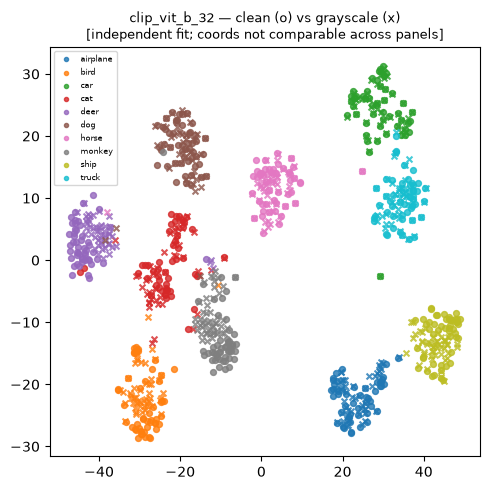

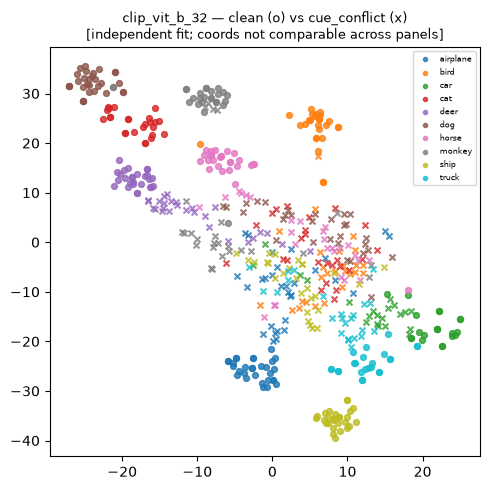

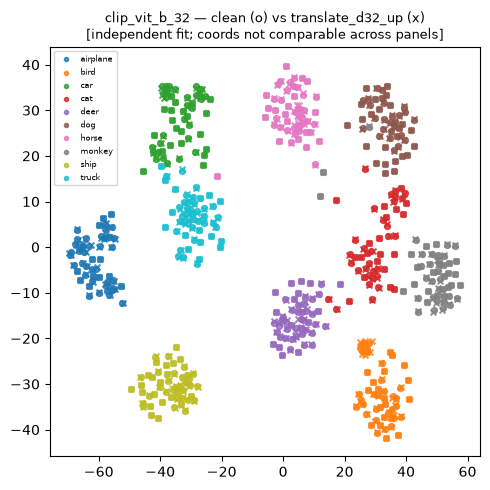

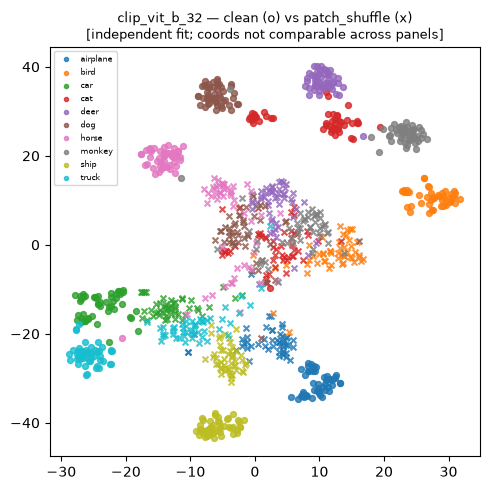

In [29]:
def plot_tsne_panel(backbone_name, condition, clean_feats, cond_feats, clean_labels):
    combined = torch.cat([clean_feats, cond_feats], dim=0).numpy()
    proj = mx.fit_2d_projection(combined, method="tsne", seed_name="tsne", perplexity=30)
    n = clean_feats.shape[0]
    proj_clean, proj_cond = proj[:n], proj[n:]

    fig, ax = plt.subplots(figsize=(5, 5))
    cmap = plt.get_cmap("tab10")
    for c in range(len(STL10_CLASSES)):
        mask = np.array(clean_labels) == c
        ax.scatter(proj_clean[mask, 0], proj_clean[mask, 1], color=cmap(c), marker="o", s=18,
                   label=STL10_CLASSES[c],
                   alpha=0.8)
        ax.scatter(proj_cond[mask, 0], proj_cond[mask, 1], color=cmap(c), marker="x", s=18, alpha=0.8)
    ax.legend(fontsize=6, markerscale=0.7)
    ax.set_title(f"{backbone_name} — clean (o) vs {condition} (x)\n[independent fit; coords not comparable across panels]", fontsize=9)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"tsne_{backbone_name}_{condition}.png", dpi=150)
    plt.show()

for backbone_name in repr_backbones:
    clean_feats = get_cached_feats(backbone_name, "clean_eval", eval_image_ids)
    for cond in REPR_CONDITIONS:
        if cond == "cue_conflict":
            cond_ids = [cuecal.cue_conflict_id(rec) for rec in accepted_records]
            cond_feats = get_cached_feats(backbone_name, cond, cond_ids)
            content_ids = [rec["content_id"] for rec in accepted_records]
            ref_feats = get_cached_feats(backbone_name, "clean_eval", content_ids)
            ref_labels = [rec["content_class_idx"] for rec in accepted_records]
            plot_tsne_panel(backbone_name, cond, ref_feats, cond_feats, ref_labels)
            continue
        cond_feats = get_cached_feats(backbone_name, cond, eval_image_ids)
        plot_tsne_panel(backbone_name, cond, clean_feats, cond_feats, eval_labels)


## 12. Summary Consolidation

A quick cross-condition view of accuracy drop and consistency for every
model, to support the write-up's overall comparison across the four
intervention families.


In [30]:
summary_rows = []
summary_rows += [{"condition": "clean", "model": r["model"], "accuracy": r["accuracy"], "consistency_vs_clean": 1.0}
                  for r in clean_baseline_df.to_dict("records")]
summary_rows += color_bias_df[["condition", "model", "accuracy", "consistency_vs_clean"]].to_dict("records")
summary_rows += patch_shuffle_df[["condition", "model", "accuracy", "consistency_vs_clean"]].to_dict("records")
summary_rows += [{"condition": f"translate_d{d}", "model": m, "accuracy": a, "consistency_vs_clean": c}
                  for d, m, a, c in translation_df[["delta", "model", "accuracy", "consistency_vs_clean"]].values]

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(RESULTS_DIR / "all_conditions_summary.csv", index=False)
summary_df.pivot_table(index="model", columns="condition", values="accuracy")


condition,clean,color_swap,grayscale,patch_shuffle,translate_d0,translate_d16,translate_d32,translate_d8
model,,,,,,,,
clip_vit_b_32_linear,0.982,0.976,0.970,0.808,0.982,0.9705,0.976,0.9765
clip_vit_b_32_zeroshot,0.958,0.952,0.952,0.790,0.958,0.9520,0.943,0.9500
resnet50,0.990,0.990,0.968,0.922,0.990,0.9875,0.985,0.9875
vit_b_16,0.994,0.996,0.976,0.942,0.994,0.9945,0.994,0.9910


## 13. Discussion

*(Fill in after a real run: compare the hypotheses stated in Steps 2–5
against the actual accuracy/consistency/I_T numbers and t-SNE panels above
— e.g. did the CNN really degrade faster under translation and patch-
shuffle than the ViT-based models? Did CLIP's zero-shot shape bias differ
from its own linear probe's? Which model's representation space was most
stable (`I_T` closest to 1) under each intervention, and does that track
with its behavioral accuracy/consistency under the same intervention?)*
